In [4]:
import numpy as np
import pandas as pd
from datetime import datetime, timezone
import json
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed_data/datacenter.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

### 异常值处理

In [3]:
df.columns

Index(['cpu_util', 'gpu0_util', 'gpu1_util', 'gpu2_util', 'gpu3_util',
       'gpu4_util', 'gpu5_util', 'gpu6_util', 'gpu7_util', 'memory', 'power',
       'Inlet_Temp', 'Outlet_Temp1', 'Outlet_Temp2'],
      dtype='object')

<Axes: >

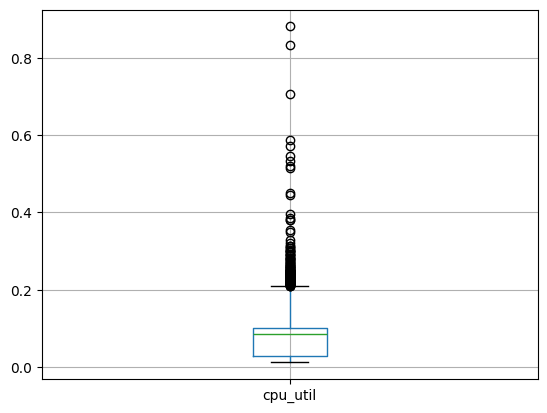

In [4]:
df.boxplot(column="cpu_util")

In [ ]:
import matplotlib.pyplot as plt

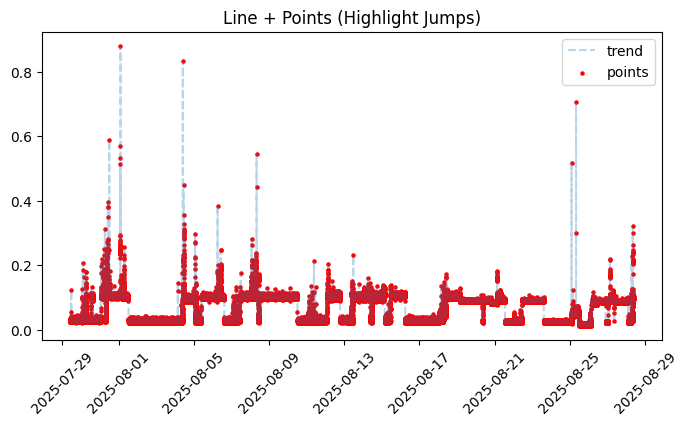

In [14]:
plt.figure(figsize=(8,4))
plt.plot(df.index, df["cpu_util"], linestyle="--", alpha=0.3, label="trend")
plt.scatter(df.index, df["cpu_util"], s=5, color="red", label="points")
plt.xticks(rotation=45)
plt.legend()
plt.title("Line + Points (Highlight Jumps)")
plt.show()

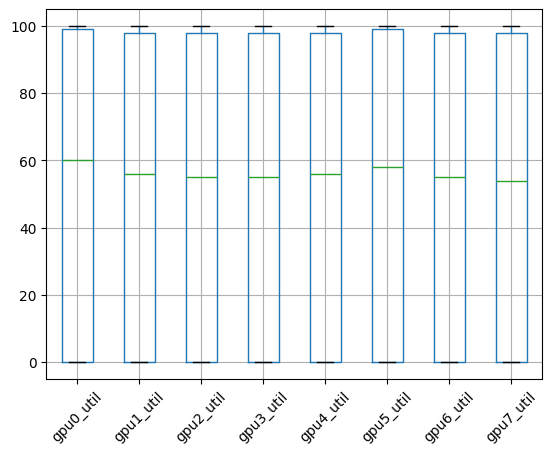

In [11]:

ax = df.boxplot(column=["gpu0_util", "gpu1_util", "gpu2_util", "gpu3_util", "gpu4_util", "gpu5_util", "gpu6_util", "gpu7_util"])
ax.tick_params(axis='x', rotation=45)
plt.show()

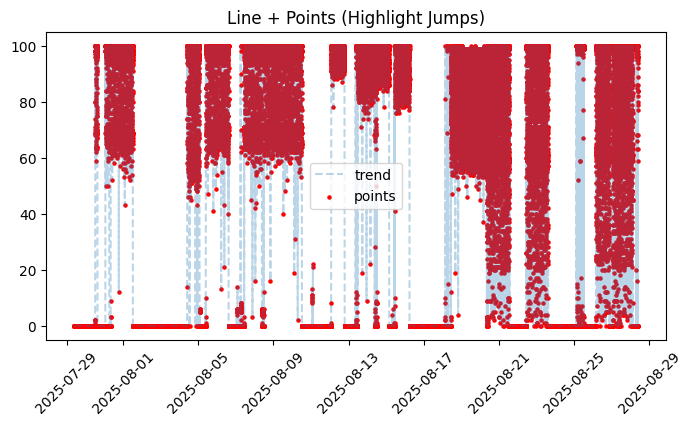

In [17]:
plt.figure(figsize=(8,4))
plt.plot(df.index, df["gpu0_util"], linestyle="--", alpha=0.3, label="trend")
plt.scatter(df.index, df["gpu0_util"], s=5, color="red", label="points")
plt.xticks(rotation=45)
plt.legend()
plt.title("Line + Points (Highlight Jumps)")
plt.show()

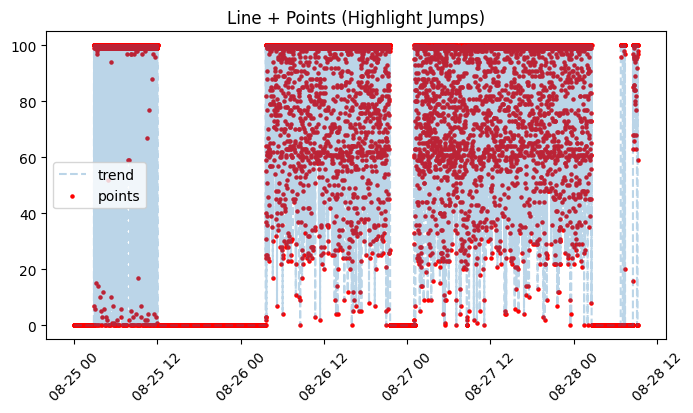

In [18]:
sub_df = df.loc["2025-08-25": "2025-08-28"]
plt.figure(figsize=(8,4))
plt.plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="trend")
plt.scatter(sub_df.index, sub_df["gpu0_util"], s=5, color="red", label="points")
plt.xticks(rotation=45)
plt.legend()
plt.title("Line + Points (Highlight Jumps)")
plt.show()

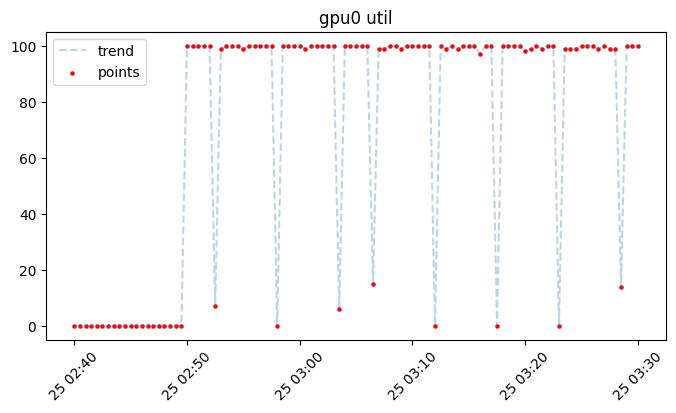

In [24]:
sub_df = df.loc["2025-08-25 02:40:00": "2025-08-25 03:30:00"]
plt.figure(figsize=(8,4))
plt.plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="trend")
plt.scatter(sub_df.index, sub_df["gpu0_util"], s=5, color="red", label="points")
plt.xticks(rotation=45)
plt.legend()
plt.title("gpu0 util")
plt.show()

上面的点可以看作异常值？

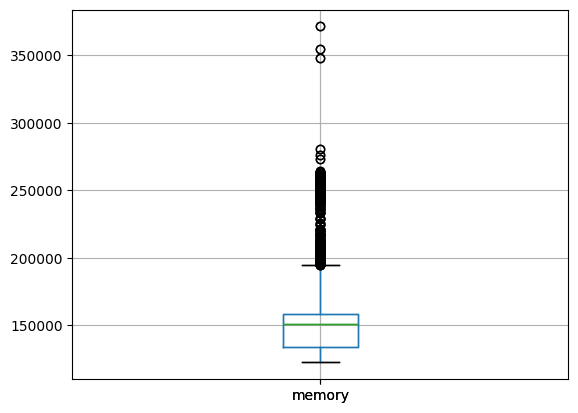

In [27]:
df.boxplot(column="memory")
plt.show()

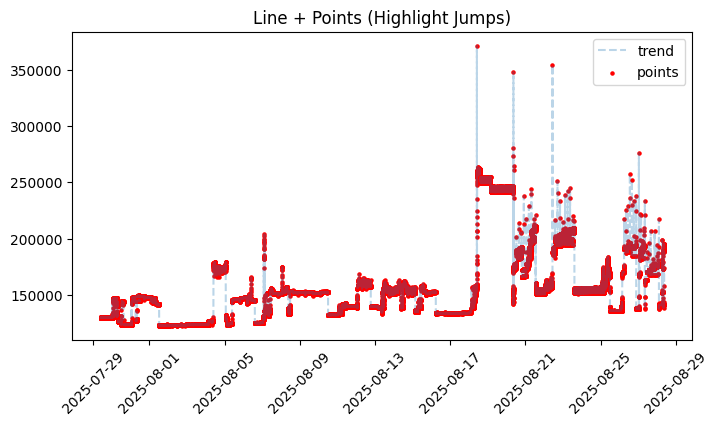

In [28]:
plt.figure(figsize=(8,4))
plt.plot(df.index, df["memory"], linestyle="--", alpha=0.3, label="trend")
plt.scatter(df.index, df["memory"], s=5, color="red", label="points")
plt.xticks(rotation=45)
plt.legend()
plt.title("Line + Points (Highlight Jumps)")
plt.show()

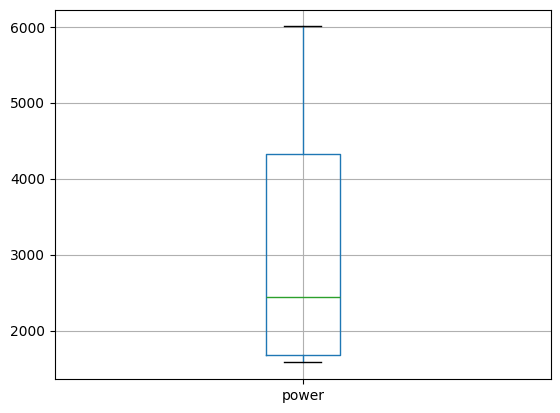

In [29]:
df.boxplot(column="power")
plt.show()

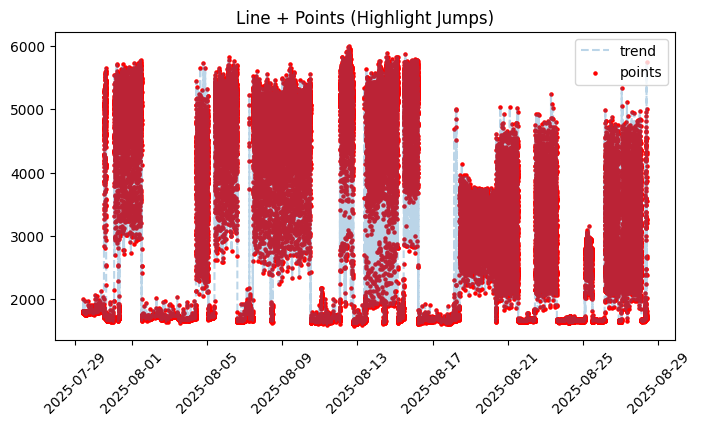

In [30]:
plt.figure(figsize=(8,4))
plt.plot(df.index, df["power"], linestyle="--", alpha=0.3, label="trend")
plt.scatter(df.index, df["power"], s=5, color="red", label="points")
plt.xticks(rotation=45)
plt.legend()
plt.title("Line + Points (Highlight Jumps)")
plt.show()

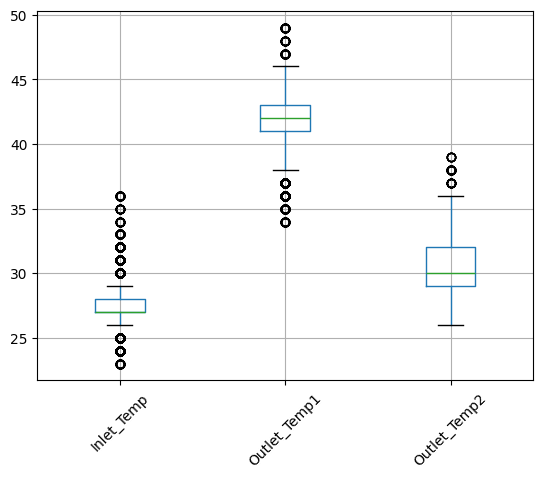

In [31]:
ax = df.boxplot(column=['Inlet_Temp', 'Outlet_Temp1', 'Outlet_Temp2'])
ax.tick_params(axis='x', rotation=45)
plt.show()

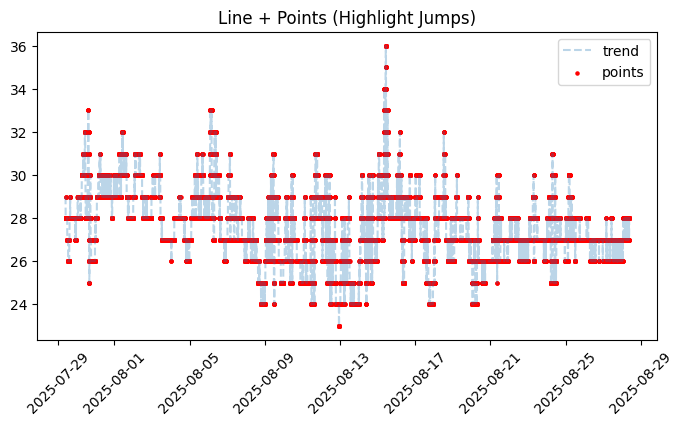

In [32]:
plt.figure(figsize=(8,4))
plt.plot(df.index, df["Inlet_Temp"], linestyle="--", alpha=0.3, label="trend")
plt.scatter(df.index, df["Inlet_Temp"], s=5, color="red", label="points")
plt.xticks(rotation=45)
plt.legend()
plt.title("Line + Points (Highlight Jumps)")
plt.show()

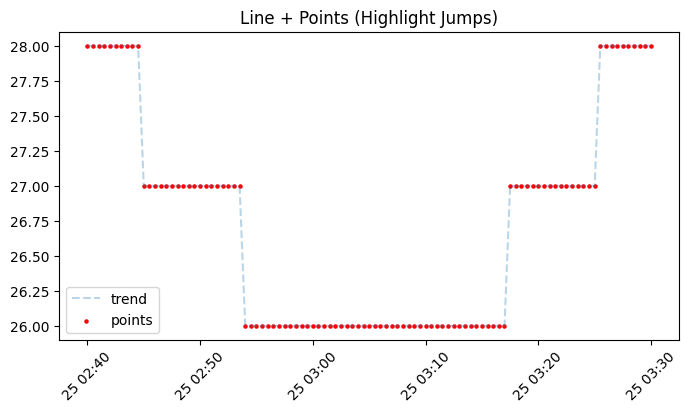

In [33]:
sub_df = df.loc["2025-08-25 02:40:00": "2025-08-25 03:30:00"]
plt.figure(figsize=(8,4))
plt.plot(sub_df.index, sub_df["Inlet_Temp"], linestyle="--", alpha=0.3, label="trend")
plt.scatter(sub_df.index, sub_df["Inlet_Temp"], s=5, color="red", label="points")
plt.xticks(rotation=45)
plt.legend()
plt.title("Line + Points (Highlight Jumps)")
plt.show()

### 缺失值统计

In [34]:
print(df.isna().sum())

cpu_util         3
gpu0_util        0
gpu1_util        0
gpu2_util        0
gpu3_util        0
gpu4_util        0
gpu5_util        0
gpu6_util        0
gpu7_util        0
memory          11
power            0
Inlet_Temp       0
Outlet_Temp1     0
Outlet_Temp2     0
dtype: int64


In [36]:
df["cpu_util"] = df["cpu_util"].interpolate(method="linear")
df["memory"] = df["memory"].interpolate(method="linear")

In [37]:
print(df.isna().sum())

cpu_util        0
gpu0_util       0
gpu1_util       0
gpu2_util       0
gpu3_util       0
gpu4_util       0
gpu5_util       0
gpu6_util       0
gpu7_util       0
memory          0
power           0
Inlet_Temp      0
Outlet_Temp1    0
Outlet_Temp2    0
dtype: int64


In [38]:
# 将GPU UTIL 转为小数
df['gpu0_util'] /= 100
df['gpu1_util'] /= 100
df['gpu2_util'] /= 100
df['gpu3_util'] /= 100
df['gpu4_util'] /= 100
df['gpu5_util'] /= 100
df['gpu6_util'] /= 100
df['gpu7_util'] /= 100

In [39]:
df.to_csv("../data/processed_data/1_datacenter.csv", index_label="timestamp")

研究GPU的波谷出现模式

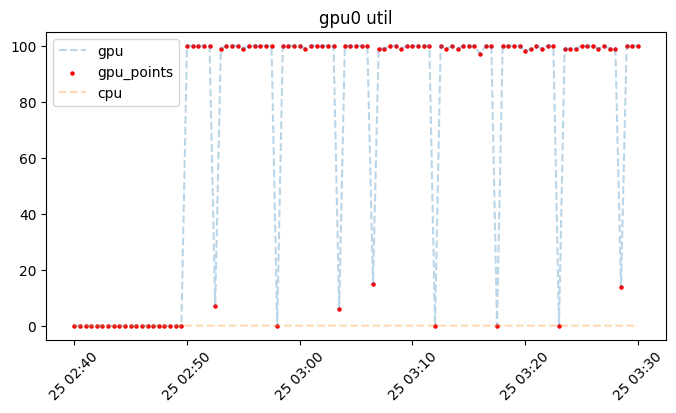

In [8]:
sub_df = df.loc["2025-08-25 02:40:00": "2025-08-25 03:30:00"]
plt.figure(figsize=(8,4))
plt.plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="gpu")
plt.scatter(sub_df.index, sub_df["gpu0_util"], s=5, color="red", label="gpu_points")
plt.plot(sub_df.index, sub_df["cpu_util"], linestyle="--", alpha=0.3, label="cpu")
# plt.plot(sub_df.index, sub_df["memory"], linestyle="--", alpha=0.3, label="trend")
plt.xticks(rotation=45)
plt.legend()
plt.title("gpu0 util")
plt.show()

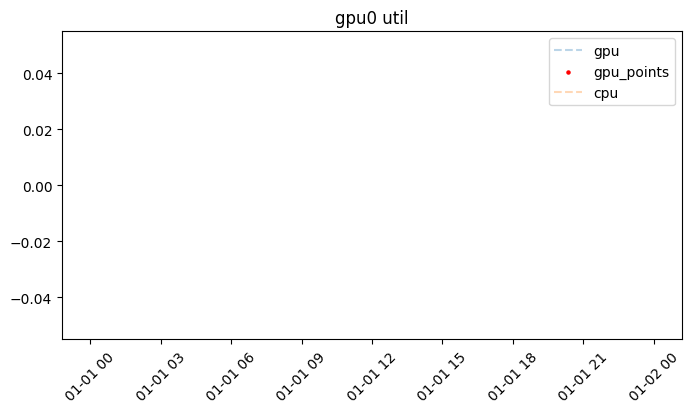

In [16]:
sub_df = df.loc["2025-07-29 00:00:00": "2025-07-29 04:00:00"]
plt.figure(figsize=(8,4))
plt.plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="gpu")
plt.scatter(sub_df.index, sub_df["gpu0_util"], s=5, color="red", label="gpu_points")
plt.plot(sub_df.index, sub_df["cpu_util"], linestyle="--", alpha=0.3, label="cpu")
# plt.plot(sub_df.index, sub_df["memory"], linestyle="--", alpha=0.3, label="trend")
plt.xticks(rotation=45)
plt.legend()
plt.title("gpu0 util")
plt.show()

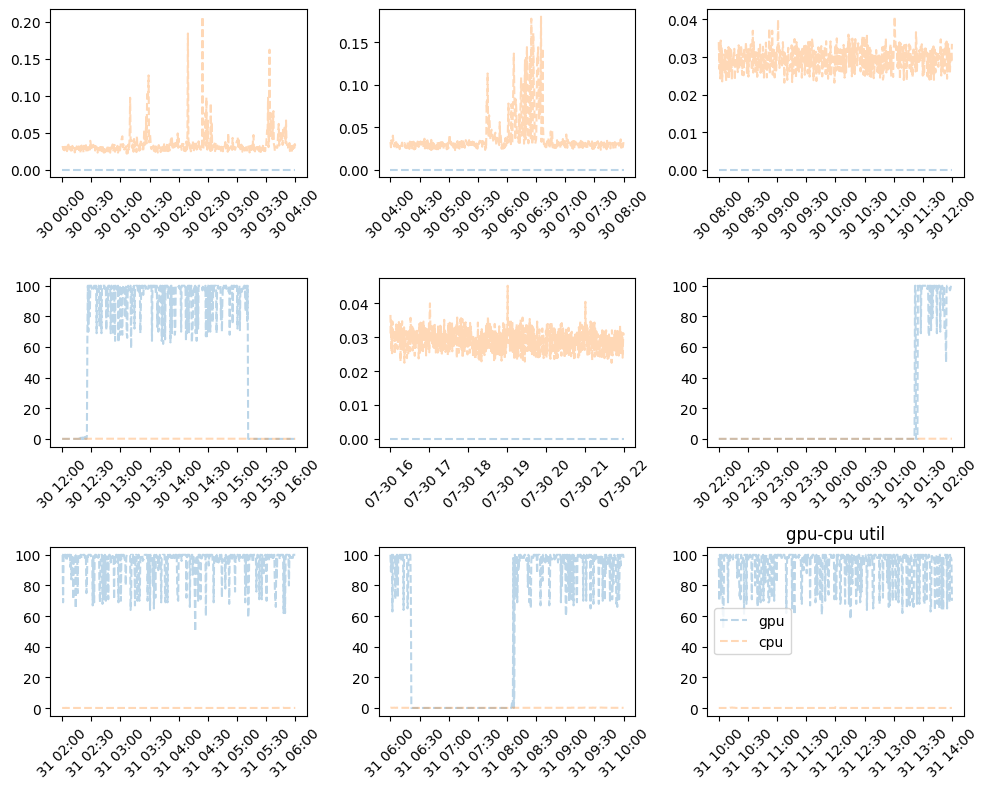

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(10, 8))

sub_df = df.loc["2025-07-30 00:00:00": "2025-07-30 04:00:00"]
axes[0,0].plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="gpu")
axes[0,0].plot(sub_df.index, sub_df["cpu_util"], linestyle="--", alpha=0.3, label="cpu")

sub_df = df.loc["2025-07-30 04:00:00": "2025-07-30 08:00:00"]
axes[0,1].plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="gpu")
axes[0,1].plot(sub_df.index, sub_df["cpu_util"], linestyle="--", alpha=0.3, label="cpu")

sub_df = df.loc["2025-07-30 08:00:00": "2025-07-30 12:00:00"]
axes[0,2].plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="gpu")
axes[0,2].plot(sub_df.index, sub_df["cpu_util"], linestyle="--", alpha=0.3, label="cpu")

sub_df = df.loc["2025-07-30 12:00:00": "2025-07-30 16:00:00"]
axes[1,0].plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="gpu")
axes[1,0].plot(sub_df.index, sub_df["cpu_util"], linestyle="--", alpha=0.3, label="cpu")

sub_df = df.loc["2025-07-30 16:00:00": "2025-07-30 22:00:00"]
axes[1,1].plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="gpu")
axes[1,1].plot(sub_df.index, sub_df["cpu_util"], linestyle="--", alpha=0.3, label="cpu")

sub_df = df.loc["2025-07-30 22:00:00": "2025-07-31 02:00:00"]
axes[1,2].plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="gpu")
axes[1,2].plot(sub_df.index, sub_df["cpu_util"], linestyle="--", alpha=0.3, label="cpu")

sub_df = df.loc["2025-07-31 02:00:00": "2025-07-31 06:00:00"]
axes[2,0].plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="gpu")
axes[2,0].plot(sub_df.index, sub_df["cpu_util"], linestyle="--", alpha=0.3, label="cpu")

sub_df = df.loc["2025-07-31 06:00:00": "2025-07-31 10:00:00"]
axes[2,1].plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="gpu")
axes[2,1].plot(sub_df.index, sub_df["cpu_util"], linestyle="--", alpha=0.3, label="cpu")

sub_df = df.loc["2025-07-31 10:00:00": "2025-07-31 14:00:00"]
axes[2,2].plot(sub_df.index, sub_df["gpu0_util"], linestyle="--", alpha=0.3, label="gpu")
axes[2,2].plot(sub_df.index, sub_df["cpu_util"], linestyle="--", alpha=0.3, label="cpu")

for i in range(3):
    for j in range(3):
        axes[i, j].tick_params(axis='x', rotation=45)

plt.legend()
plt.title("gpu-cpu util")
plt.tight_layout()
plt.show()

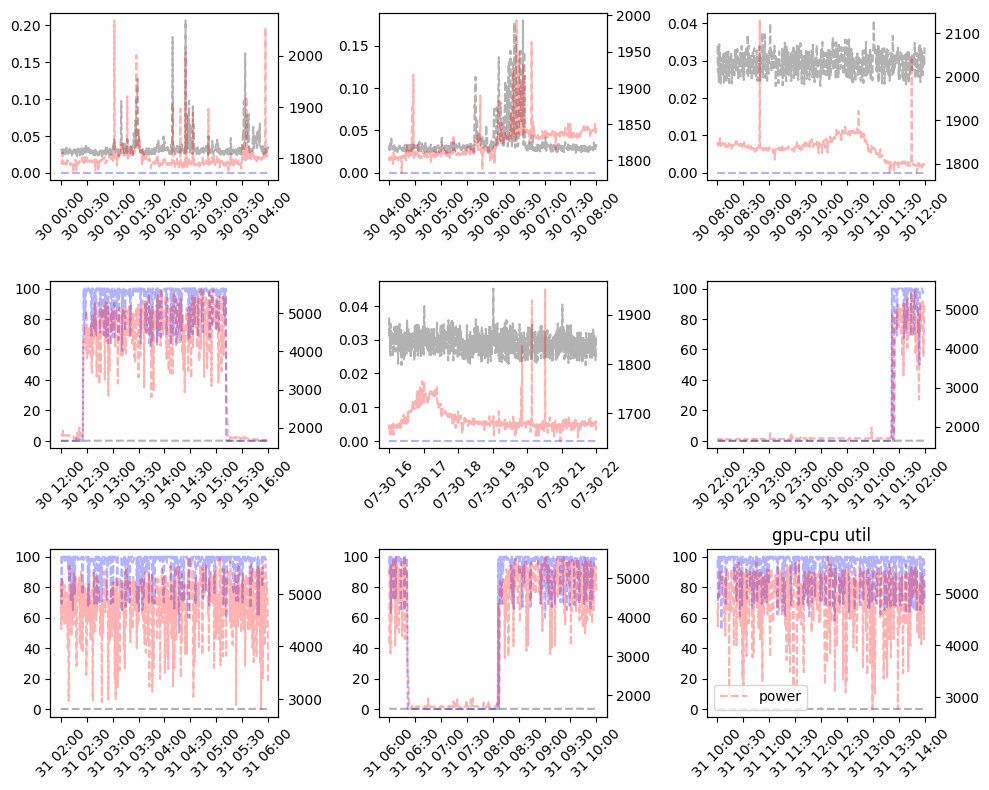

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(10, 8))

sub_df = df.loc["2025-07-30 00:00:00": "2025-07-30 04:00:00"]
axes[0,0].plot(sub_df.index, sub_df["gpu0_util"], color='blue', linestyle="--", alpha=0.3, label="gpu")
axes[0,0].plot(sub_df.index, sub_df["cpu_util"], color='black', linestyle="--", alpha=0.3, label="cpu")
axes[0,0].twinx().plot(sub_df.index, sub_df["power"], color='red', linestyle="--", alpha=0.3, label="power")


sub_df = df.loc["2025-07-30 04:00:00": "2025-07-30 08:00:00"]
axes[0,1].plot(sub_df.index, sub_df["gpu0_util"], color='blue',linestyle="--", alpha=0.3, label="gpu")
axes[0,1].plot(sub_df.index, sub_df["cpu_util"], color='black', linestyle="--", alpha=0.3, label="cpu")
axes[0,1].twinx().plot(sub_df.index, sub_df["power"], color='red',linestyle="--", alpha=0.3, label="power")

sub_df = df.loc["2025-07-30 08:00:00": "2025-07-30 12:00:00"]
axes[0,2].plot(sub_df.index, sub_df["gpu0_util"], color='blue',linestyle="--", alpha=0.3, label="gpu")
axes[0,2].plot(sub_df.index, sub_df["cpu_util"], color='black', linestyle="--", alpha=0.3, label="cpu")
axes[0,2].twinx().plot(sub_df.index, sub_df["power"], color='red',linestyle="--", alpha=0.3, label="power")

sub_df = df.loc["2025-07-30 12:00:00": "2025-07-30 16:00:00"]
axes[1,0].plot(sub_df.index, sub_df["gpu0_util"], color='blue',linestyle="--", alpha=0.3, label="gpu")
axes[1,0].plot(sub_df.index, sub_df["cpu_util"], color='black', linestyle="--", alpha=0.3, label="cpu")
axes[1,0].twinx().plot(sub_df.index, sub_df["power"], color='red',linestyle="--", alpha=0.3, label="power")

sub_df = df.loc["2025-07-30 16:00:00": "2025-07-30 22:00:00"]
axes[1,1].plot(sub_df.index, sub_df["gpu0_util"], color='blue',linestyle="--", alpha=0.3, label="gpu")
axes[1,1].plot(sub_df.index, sub_df["cpu_util"], color='black', linestyle="--", alpha=0.3, label="cpu")
axes[1,1].twinx().plot(sub_df.index, sub_df["power"], color='red',linestyle="--", alpha=0.3, label="power")

sub_df = df.loc["2025-07-30 22:00:00": "2025-07-31 02:00:00"]
axes[1,2].plot(sub_df.index, sub_df["gpu0_util"], color='blue',linestyle="--", alpha=0.3, label="gpu")
axes[1,2].plot(sub_df.index, sub_df["cpu_util"], color='black', linestyle="--", alpha=0.3, label="cpu")
axes[1,2].twinx().plot(sub_df.index, sub_df["power"], color='red',linestyle="--", alpha=0.3, label="power")

sub_df = df.loc["2025-07-31 02:00:00": "2025-07-31 06:00:00"]
axes[2,0].plot(sub_df.index, sub_df["gpu0_util"], color='blue',linestyle="--", alpha=0.3, label="gpu")
axes[2,0].plot(sub_df.index, sub_df["cpu_util"], color='black', linestyle="--", alpha=0.3, label="cpu")
axes[2,0].twinx().plot(sub_df.index, sub_df["power"], color='red',linestyle="--", alpha=0.3, label="power")

sub_df = df.loc["2025-07-31 06:00:00": "2025-07-31 10:00:00"]
axes[2,1].plot(sub_df.index, sub_df["gpu0_util"], color='blue',linestyle="--", alpha=0.3, label="gpu")
axes[2,1].plot(sub_df.index, sub_df["cpu_util"], color='black', linestyle="--", alpha=0.3, label="cpu")
axes[2,1].twinx().plot(sub_df.index, sub_df["power"], color='red',linestyle="--", alpha=0.3, label="power")

sub_df = df.loc["2025-07-31 10:00:00": "2025-07-31 14:00:00"]
axes[2,2].plot(sub_df.index, sub_df["gpu0_util"], color='blue',linestyle="--", alpha=0.3, label="gpu")
axes[2,2].plot(sub_df.index, sub_df["cpu_util"], color='black', linestyle="--", alpha=0.3, label="cpu")
axes[2,2].twinx().plot(sub_df.index, sub_df["power"], color='red',linestyle="--", alpha=0.3, label="power")

for i in range(3):
    for j in range(3):
        axes[i, j].tick_params(axis='x', rotation=45)

plt.legend()
plt.title("gpu-cpu util")
plt.tight_layout()
plt.show()

## 相关系数

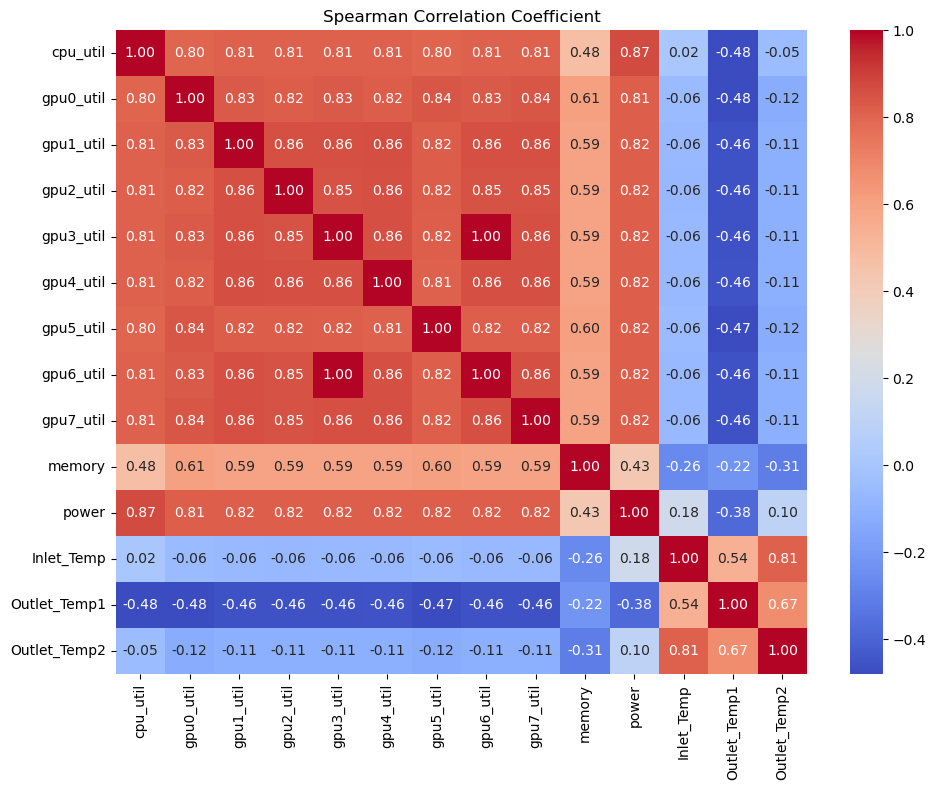

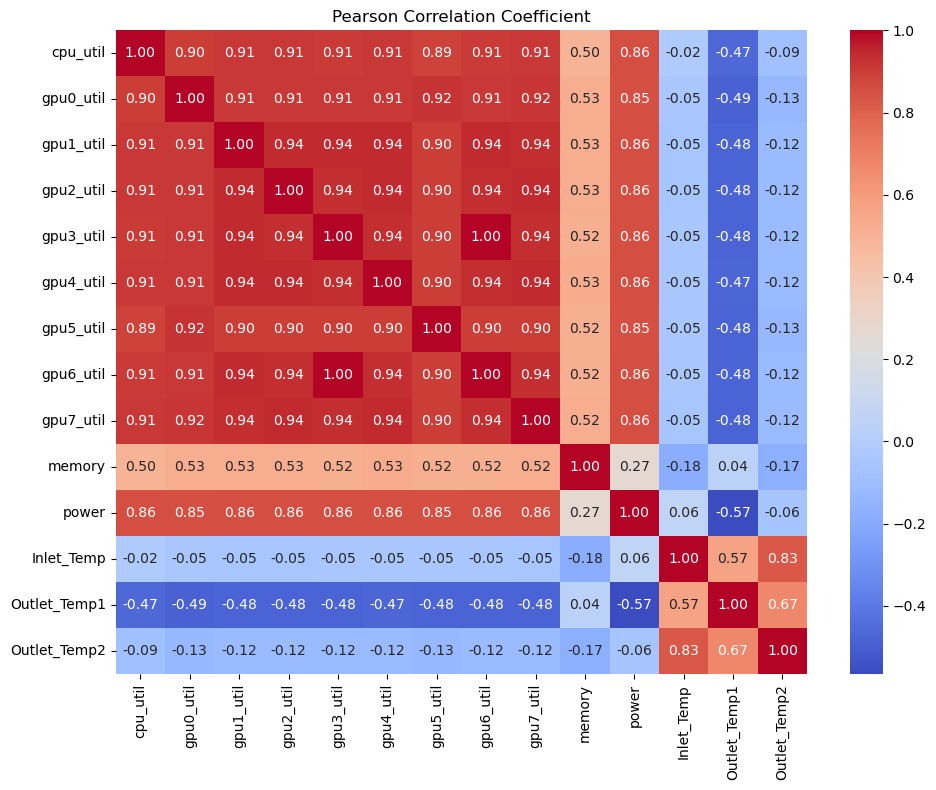

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_csv("../data/processed_data/1_datacenter.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# 需要分析的参数
cols = [
    'cpu_util', 'gpu0_util', 'gpu1_util', 'gpu2_util', 'gpu3_util',
    'gpu4_util', 'gpu5_util', 'gpu6_util', 'gpu7_util', 'memory', 'power',
    'Inlet_Temp', 'Outlet_Temp1', 'Outlet_Temp2'
]

# 只保留相关列
df_corr = df[cols]

spearman_corr = df_corr.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Spearman Correlation Coefficient")
plt.tight_layout()
plt.show()

pearson_corr = df_corr.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Pearson Correlation Coefficient")
plt.tight_layout()
plt.show()